In [8]:
import sys
import os

sys.path.append("retail-ai-pytorch/src")

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
from model import RetailModel
from train import train_model
from evaluation import plot_training

In [13]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

merge dataset

In [14]:
train = train.merge(features, on=["Store","Date","IsHoliday"])
train = train.merge(stores, on="Store")

test = test.merge(features, on=["Store","Date","IsHoliday"])
test = test.merge(stores, on="Store")

feature engineering

In [15]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

train["Year"] = train["Date"].dt.year
train["Month"] = train["Date"].dt.month
train["Week"] = train["Date"].dt.isocalendar().week

test["Year"] = test["Date"].dt.year
test["Month"] = test["Date"].dt.month
test["Week"] = test["Date"].dt.isocalendar().week

missing values

In [16]:
train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

Encode Categorical Variables

In [17]:
train = pd.get_dummies(train, columns=["Type"])
test = pd.get_dummies(test, columns=["Type"])

train["IsHoliday"] = train["IsHoliday"].astype(int)
test["IsHoliday"] = test["IsHoliday"].astype(int)

In [18]:
train = train.drop(["Date"], axis=1)
test = test.drop(["Date"], axis=1)

In [19]:
X = train.drop("Weekly_Sales", axis=1)
y = train["Weekly_Sales"]

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(test)

convert to pytorch

In [22]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

reshape for cnn

In [23]:
X_train = X_train.unsqueeze(1)
X_val = X_val.unsqueeze(1)
X_test = X_test.unsqueeze(1)

In [24]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=512
)

In [25]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = RetailModel(X_train.shape[2])

model.to(device)

RetailModel(
  (conv1): Conv1d(1, 32, kernel_size=(2,), stride=(1,))
  (lstm): LSTM(32, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

In [27]:
train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    device=device
)

Epoch [1/20] Train Loss: 761097269.4143 Val Loss: 752271675.9273
Epoch [2/20] Train Loss: 717090011.0470 Val Loss: 692996426.0848
Epoch [3/20] Train Loss: 651684349.0379 Val Loss: 625551032.2424
Epoch [4/20] Train Loss: 589197130.1002 Val Loss: 570693157.8182
Epoch [5/20] Train Loss: 545095891.1320 Val Loss: 537786726.0121
Epoch [6/20] Train Loss: 522695357.5235 Val Loss: 524655855.1273
Epoch [7/20] Train Loss: 508598047.3687 Val Loss: 508399589.2364
Epoch [8/20] Train Loss: 498911762.3794 Val Loss: 502888466.8121
Epoch [9/20] Train Loss: 496256204.2367 Val Loss: 501688127.2242
Epoch [10/20] Train Loss: 495886461.9605 Val Loss: 501581567.0303
Epoch [11/20] Train Loss: 495913938.3551 Val Loss: 501519847.5636
Epoch [12/20] Train Loss: 495778619.6540 Val Loss: 501466639.5152
Epoch [13/20] Train Loss: 470650417.2868 Val Loss: 436995556.6545
Epoch [14/20] Train Loss: 417394875.9939 Val Loss: 407081272.5333
Epoch [15/20] Train Loss: 383755480.3520 Val Loss: 372805679.2242
Epoch [16/20] Train

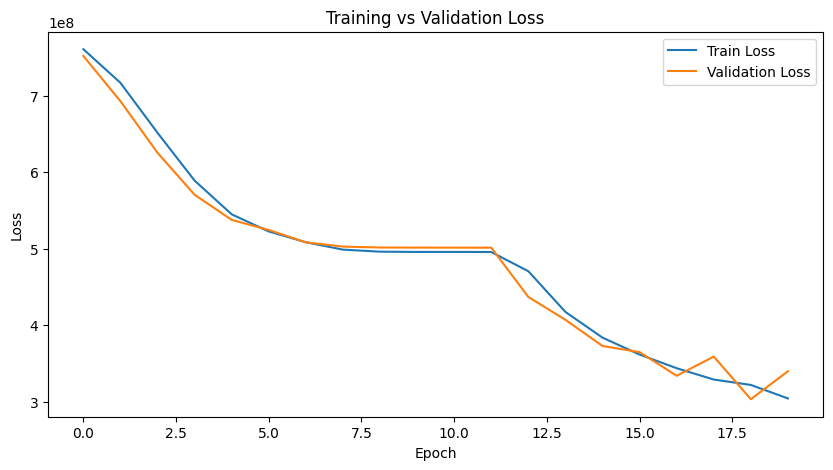

In [30]:
plot_training(
    train_losses,
    val_losses
)

In [31]:
model.eval()

with torch.no_grad():
    predictions = model(X_val.to(device))

predictions = predictions.cpu().numpy()

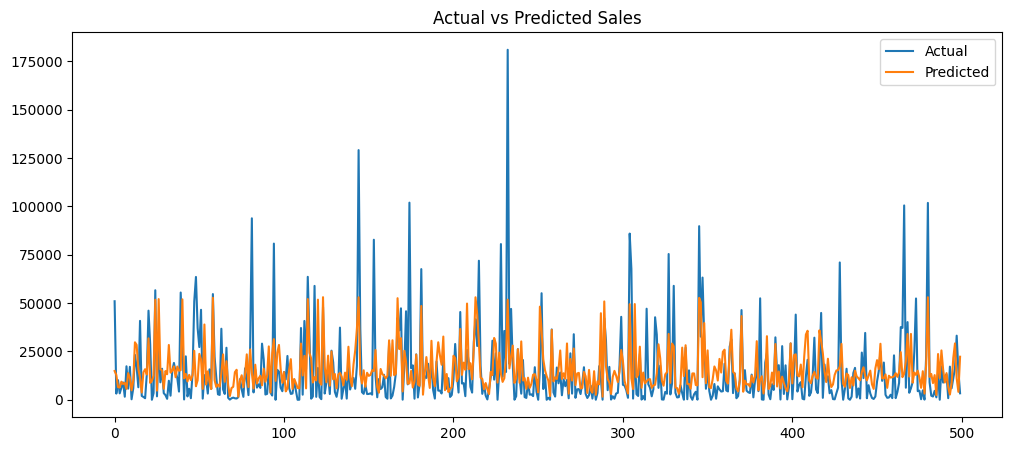

In [32]:
plt.figure(figsize=(12,5))

plt.plot(y_val[:500], label="Actual")
plt.plot(predictions[:500], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Sales")

plt.savefig(
    "retail-ai-pytorch/plots/prediction_vs_actual.png"
)

plt.show()